In [5]:
import numpy as np
import matplotlib.pyplot as plt

def crystal_ball(x, alpha, n, mu, sigma):
    x = (x - mu) / sigma
    A = (n / abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)

    result = np.where(
        x > -alpha,
        np.exp(-0.5 * x**2),                 # Gaussian part
        A * (B - x)**(-n)                   # Power-law tail
    )
    return result

def double_crystal_ball(x, alphaL, nL, alphaR, nR, mu, sigma):
    x = (x - mu) / sigma

    AL = (nL / abs(alphaL))**nL * np.exp(-alphaL**2 / 2)
    BL = nL / abs(alphaL) - abs(alphaL)

    AR = (nR / abs(alphaR))**nR * np.exp(-alphaR**2 / 2)
    BR = nR / abs(alphaR) - abs(alphaR)

    result = np.piecewise(
        x,
        [x < -alphaL, (x >= -alphaL) & (x <= alphaR), x > alphaR],
        [
            lambda x: AL * (BL - x)**(-nL),   # Left tail
            lambda x: np.exp(-0.5 * x**2),    # Gaussian core
            lambda x: AR * (BR + x)**(-nR)    # Right tail
        ]
    )
    return result
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma)**2)

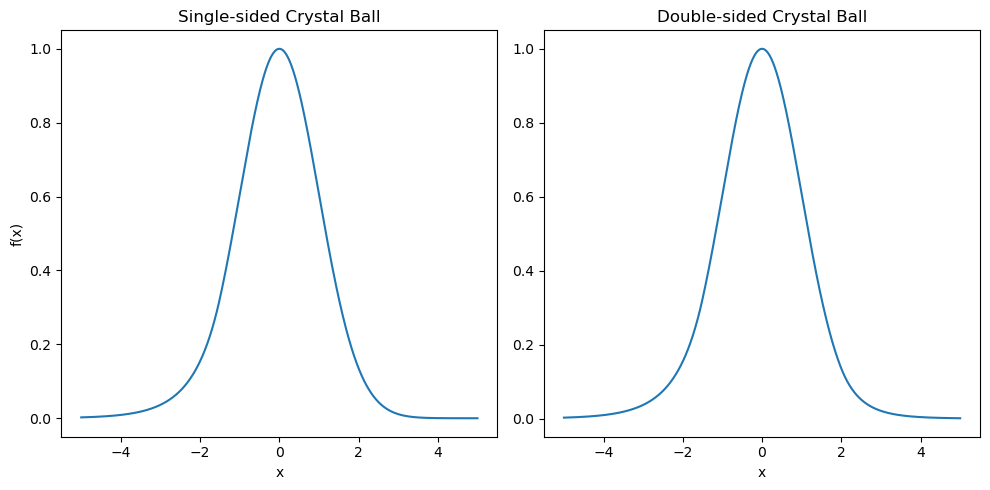

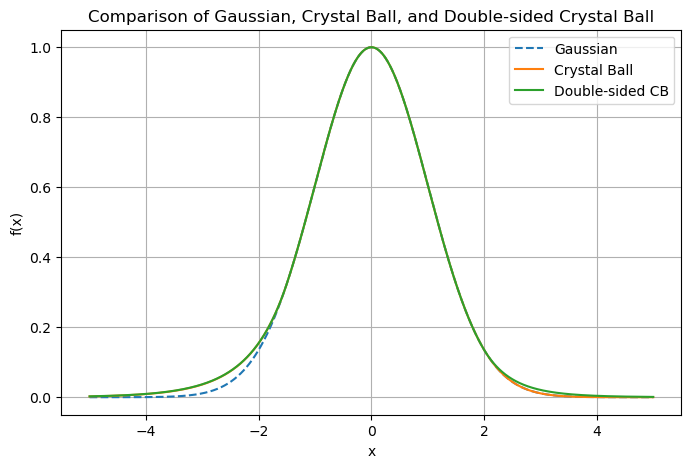

In [6]:
# x range
x = np.linspace(-5, 5, 1000)

# Single-sided crystal ball
y_cb = crystal_ball(x, alpha=1.5, n=40, mu=0, sigma=1)

# Double-sided crystal ball
y_dcb = double_crystal_ball(x, alphaL=1.5, nL=31, alphaR=2.0, nR=14, mu=0, sigma=1)

y_gauss = gaussian(x, mu=0, sigma=1)

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(x, y_cb)
plt.title("Single-sided Crystal Ball")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.subplot(1,2,2)
plt.plot(x, y_dcb)
plt.title("Double-sided Crystal Ball")
plt.xlabel("x")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(x, y_gauss, label="Gaussian", linestyle="--")
plt.plot(x, y_cb, label="Crystal Ball")
plt.plot(x, y_dcb, label="Double-sided CB")

plt.title("Comparison of Gaussian, Crystal Ball, and Double-sided Crystal Ball")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)

plt.show()